Лабораториска вежба 4 – Квантизација

Задача 1

 Користејќи го моделот LLaMA-2 со квантизација со 4bits со
техниката few-shot prompting за секој примерок од податочното множество
одредете дали примерокот содржи позитивен или негативен сентимент. Испробајте
со користење различен број на примероци (n = 0, 1, 5, 10).
Добиените предвидувања евалуирајте ги со метриките: точност
(accuracy_score), прецизност (precision_score), одзив (recall_score) и F1-
мерка (f1_score).

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [ ]:
data = pd.read_csv("test_en_parallel.txt", sep="\t", header=None)
data.columns = ["Negative", "Positive"]
data.head()

,Negative,Positive
0,Style 1,Style 2
1,ever since joes has changed hands it's just go...,Ever since joes has changed hands it's gotten ...
2,there is definitely not enough room in that pa...,There is so much room in that part of the venue
3,so basically tasted watered down.,It didn't taste watered down at all.
4,she said she'd be back and disappeared for a f...,"She said she'd be back, and didn't disappear a..."


In [ ]:
data = data.iloc[1:].reset_index(drop=True)
data.head()


,Negative,Positive
0,ever since joes has changed hands it's just go...,Ever since joes has changed hands it's gotten ...
1,there is definitely not enough room in that pa...,There is so much room in that part of the venue
2,so basically tasted watered down.,It didn't taste watered down at all.
3,she said she'd be back and disappeared for a f...,"She said she'd be back, and didn't disappear a..."
4,i can't believe how inconsiderate this pharmac...,This pharmacy is really considerate.


In [ ]:
print(data["Negative"].iloc[0])
print(data["Positive"].iloc[0])


ever since joes has changed hands it's just gotten worse and worse.
Ever since joes has changed hands it's gotten better and better.


In [ ]:
neg_df = pd.DataFrame({
    "text": data["Negative"],
    "label": "NEG"
})

pos_df = pd.DataFrame({
    "text": data["Positive"],
    "label": "POS"
})

cls_data = pd.concat([neg_df, pos_df], ignore_index=True)
cls_data = cls_data.sample(frac=1, random_state=42).reset_index(drop=True)

cls_data.head()


,text,label
0,"place was clean and well kept, drinks were rea...",POS
1,it didn't matter of she is good at all other t...,NEG
2,Everything was hot including the coffee.,POS
3,won't go back with friends,NEG
4,this place is beyond a great place.,POS


In [ ]:
def build_prompt(text, shots=None):
    instruction = (
        "You are a sentiment classifier.\n"
        "Decide whether the sentiment of the given text is POS or NEG.\n"
        "Output ONLY one token: POS or NEG.\n\n"
    )

    examples = ""
    if shots:
        for s in shots:
            examples += f"Text: {s['text']}\nLabel: {s['label']}\n\n"

    query = f"Text: {text}\nLabel:"
    return instruction + examples + query


In [ ]:
test_text = cls_data.loc[0, "text"]
prompt = build_prompt(test_text)
print(prompt)


You are a sentiment classifier.
Decide whether the sentiment of the given text is POS or NEG.
Output ONLY one token: POS or NEG.

Text: place was clean and well kept, drinks were reasonably priced.
Label:


In [ ]:
#one shot
shot = {
    "text": cls_data.loc[1, "text"],
    "label": cls_data.loc[1, "label"]
}

prompt_1shot = build_prompt(test_text, shots=[shot])
print(prompt_1shot)


You are a sentiment classifier.
Decide whether the sentiment of the given text is POS or NEG.
Output ONLY one token: POS or NEG.

Text: it didn't matter of she is good at all other times.
Label: NEG

Text: place was clean and well kept, drinks were reasonably priced.
Label:


In [ ]:
#random shots
import random

def get_shots(df, n, exclude_idx, seed=42):
    if n == 0:
        return []
    candidates = df.drop(index=exclude_idx)
    rnd = random.Random(seed + exclude_idx)
    idxs = rnd.sample(list(candidates.index), k=n)
    return candidates.loc[idxs, ["text", "label"]].to_dict("records")


In [ ]:
i = 0
shots_5 = get_shots(cls_data, n=5, exclude_idx=i)
prompt_5shot = build_prompt(cls_data.loc[i, "text"], shots=shots_5)

print(prompt_5shot[:1200])


You are a sentiment classifier.
Decide whether the sentiment of the given text is POS or NEG.
Output ONLY one token: POS or NEG.

Text: now the food : not bad, above average.
Label: POS

Text: you can not judge people based on appearance.
Label: NEG

Text: It's a very pleasant surprise.
Label: POS

Text: ambiance and setting were sub-par.
Label: NEG

Text: she didn't keep our drinks full and gave us poor food recommendations.
Label: NEG

Text: place was clean and well kept, drinks were reasonably priced.
Label:


In [ ]:
i = 0

shots_10 = get_shots(cls_data, n=10, exclude_idx=i)
prompt_10shot = build_prompt(cls_data.loc[i, "text"], shots=shots_10)

print(prompt_10shot[:1200])


You are a sentiment classifier.
Decide whether the sentiment of the given text is POS or NEG.
Output ONLY one token: POS or NEG.

Text: now the food : not bad, above average.
Label: POS

Text: you can not judge people based on appearance.
Label: NEG

Text: It's a very pleasant surprise.
Label: POS

Text: ambiance and setting were sub-par.
Label: NEG

Text: she didn't keep our drinks full and gave us poor food recommendations.
Label: NEG

Text: the happy hour crowd here is never fun.
Label: NEG

Text: the atmosphere was fun and the staff treats you well.
Label: POS

Text: it is not really brown rice.
Label: NEG

Text: she did offer me a copy if i would like a soda while waiting.
Label: NEG

Text: they are all very friendly.
Label: POS

Text: place was clean and well kept, drinks were reasonably priced.
Label:


In [ ]:
from huggingface_hub import login
login()


In [ ]:
from huggingface_hub import model_info

model_info("meta-llama/Llama-2-7b-chat-hf")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


ModelInfo(id='meta-llama/Llama-2-7b-chat-hf', author='meta-llama', sha='f5db02db724555f92da89c216ac04704f23d4590', created_at=datetime.datetime(2023, 7, 13, 16, 45, 23, tzinfo=datetime.timezone.utc), last_modified=datetime.datetime(2024, 4, 17, 8, 40, 48, tzinfo=datetime.timezone.utc), private=False, disabled=False, downloads=331479, downloads_all_time=None, gated='manual', gguf=None, inference=None, inference_provider_mapping=None, likes=4680, library_name='transformers', tags=['transformers', 'pytorch', 'safetensors', 'llama', 'text-generation', 'facebook', 'meta', 'llama-2', 'conversational', 'en', 'arxiv:2307.09288', 'license:llama2', 'text-generation-inference', 'endpoints_compatible', 'region:us'], pipeline_tag='text-generation', mask_token=None, card_data={'base_model': None, 'datasets': None, 'eval_results': None, 'language': ['en'], 'library_name': None, 'license': 'llama2', 'license_name': None, 'license_link': None, 'metrics': None, 'model_name': None, 'pipeline_tag': 'text-

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


In [ ]:
 # !pip install -U bitsandbytes accelerate transformers
!pip uninstall -y bitsandbytes



Found existing installation: bitsandbytes 0.49.0
Uninstalling bitsandbytes-0.49.0:
  Successfully uninstalled bitsandbytes-0.49.0


In [ ]:
!pip install -U bitsandbytes


  Using cached bitsandbytes-0.49.0-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
Using cached bitsandbytes-0.49.0-py3-none-manylinux_2_24_x86_64.whl (59.1 MB)


In [ ]:
import bitsandbytes as bnb
bnb.__version__


'0.49.0'

In [ ]:
model_name = "meta-llama/Llama-2-7b-chat-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [ ]:
@torch.inference_mode()
def predict_label(text, shots=None):
    prompt = build_prompt(text, shots=shots)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = decoded[len(prompt):].strip().upper()

    if answer.startswith("POS"):
        return "POS"
    if answer.startswith("NEG"):
        return "NEG"

    return answer


In [ ]:
#one shot
i = 0
shots_1 = get_shots(cls_data, n=1, exclude_idx=i)

print("TEXT:", cls_data.loc[i, "text"])
print("TRUE:", cls_data.loc[i, "label"])
print("PRED (1-shot):", predict_label(cls_data.loc[i, "text"], shots=shots_1))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


TEXT: place was clean and well kept, drinks were reasonably priced.
TRUE: POS
PRED (1-shot): POS


In [ ]:
#5shots
i = 25
shots_5 = get_shots(cls_data, n=5, exclude_idx=i)

print("TEXT:", cls_data.loc[i, "text"])
print("TRUE:", cls_data.loc[i, "label"])
print("PRED:", predict_label(cls_data.loc[i, "text"], shots=shots_5))


TEXT: but this place was not economical so the expectation was different.
TRUE: NEG
PRED: NEG


In [ ]:
#5shots
i = 0
shots_5 = get_shots(cls_data, n=5, exclude_idx=i)

print("TEXT:", cls_data.loc[i, "text"])
print("TRUE:", cls_data.loc[i, "label"])
print("PRED:", predict_label(cls_data.loc[i, "text"], shots=shots_5))


TEXT: place was clean and well kept, drinks were reasonably priced.
TRUE: POS
PRED: POS


In [ ]:
def evaluate_n_shots(df, n, limit=200):
    y_true, y_pred = [], []
    invalid_cnt = 0

    for i in range(min(limit, len(df))):
        shots = get_shots(df, n=n, exclude_idx=i)
        pred = predict_label(df.loc[i, "text"], shots=shots)

        y_true.append(df.loc[i, "label"])


        if pred not in ["POS", "NEG"]:
            invalid_cnt += 1
            pred = "NEG"

        y_pred.append(pred)

    return {
        "n_shots": n,
        "samples": min(limit, len(df)),
        "invalid": invalid_cnt,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="POS"),
        "recall": recall_score(y_true, y_pred, pos_label="POS"),
        "f1": f1_score(y_true, y_pred, pos_label="POS"),
    }


In [ ]:
results = []
for n in [0, 1, 5, 10]:
    results.append(evaluate_n_shots(cls_data, n=n, limit=100))

pd.DataFrame(results)


,n_shots,samples,invalid,accuracy,precision,recall,f1
0,0,100,4,0.85,0.779412,1.000000,0.876033
1,1,100,0,0.77,0.750000,0.849057,0.796460
2,5,100,0,0.85,0.816667,0.924528,0.867257
3,10,100,0,0.93,0.910714,0.962264,0.935780


Резултатите на моделот LLaMA-2 со 4-битна квантизација покажуваат дека моделот постигнува солидна точност и во zero-shot поставка (85%), додека со зголемување на бројот на примери во prompt-от се забележува јасно подобрување. Најдобра перформанса е постигната со 10-shot prompting, со точност од 93% и F1-мерка од 0.936.


Моделот LLaMA-2 не е стриктно подобар од моделите користени во претходните лабораториски вежби, туку нуди пофлексибилен пристап преку few-shot prompting без дополнително тренирање. Претходните модели се поефикасни и побрзи за конкретни задачи, додека LLaMA-2 овозможува поширока примена и адаптабилност.

Задача 2

Користејќи го моделот LLaMA-2 со квантизација со 4bits со техниката few-shot
prompting за секој примерок од податочното множествo што содржи негативен
сентимент генерирајте реченица што содржи позитивен сентимент. Испробајте со
користење различен број на примероци (n = 0, 1, 5, 10).
Добиените предвидувања евалуирајте ги со метриките: BLEU и BERTScore.


In [ ]:
import pandas as pd
import torch
import random
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig


In [ ]:
data = data.iloc[1:].reset_index(drop=True)
data.head()


,Negative,Positive
0,there is definitely not enough room in that pa...,There is so much room in that part of the venue
1,so basically tasted watered down.,It didn't taste watered down at all.
2,she said she'd be back and disappeared for a f...,"She said she'd be back, and didn't disappear a..."
3,i can't believe how inconsiderate this pharmac...,This pharmacy is really considerate.
4,just left and took it off the bill.,just left and put it on the bill.


In [ ]:
data_small = data.sample(n=100, random_state=42).reset_index(drop=True)


In [ ]:
model_name = "meta-llama/Llama-2-7b-chat-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


In [ ]:
def build_prompt_generation(neg_text, shots=None):
    instruction = (
        "You are a helpful assistant.\n"
        "Rewrite the sentence to express a POSITIVE sentiment.\n"
        "Keep the topic and meaning as much as possible, but make it positive.\n"
        "Output ONLY the rewritten positive sentence.\n\n"
    )

    examples = ""
    if shots:
        for s in shots:
            examples += f"Negative: {s['neg']}\nPositive: {s['pos']}\n\n"

    query = f"Negative: {neg_text}\nPositive:"
    return instruction + examples + query


In [ ]:
def get_gen_shots(df, n, exclude_idx, seed=42):
    if n == 0:
        return []
    rnd = random.Random(seed + exclude_idx)
    idxs = list(range(len(df)))
    idxs.remove(exclude_idx)
    chosen = rnd.sample(idxs, k=n)
    return [{"neg": df.loc[j, "Negative"], "pos": df.loc[j, "Positive"]} for j in chosen]


In [ ]:
@torch.inference_mode()
def generate_positive(neg_text, shots=None, max_new_tokens=60):
    prompt = build_prompt_generation(neg_text, shots=shots)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    gen = decoded[len(prompt):].strip()

    # cleaning if the model add new line
    gen = gen.split("\n")[0].strip()
    return gen


In [ ]:
# zero shot and five shot
i = 0
neg = data_small.loc[i, "Negative"]
ref = data_small.loc[i, "Positive"]

print("NEG:", neg)
print("REF POS:", ref)

print("\n0-shot:", generate_positive(neg, shots=[]))

shots_5 = get_gen_shots(data_small, n=5, exclude_idx=i)
print("\n5-shot:", generate_positive(neg, shots=shots_5))


NEG: firstly, their fees are generally higher than other places.
REF POS: The fees are comparable to other places.

0-shot: firstly, their fees are competitive and offer great value for money.

5-shot: Firstly, their fees are comparable to other places.


In [ ]:
#different n
for n in [0, 1, 5, 10]:
    shots = get_gen_shots(data_small, n=n, exclude_idx=i)
    out = generate_positive(neg, shots)
    print(f"\n=== {n}-SHOT ===")
    print(out)



=== 0-SHOT ===
firstly, their fees are competitive and offer great value for money.

=== 1-SHOT ===
Firstly, their fees are competitive and affordable.

=== 5-SHOT ===
Firstly, their fees are comparable to other places.

=== 10-SHOT ===
firstly, their fees are generally lower than other places.


In [ ]:
!pip -q install evaluate bert-score sacrebleu


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 11.0 MB/s eta 0:00:00


In [ ]:
import evaluate
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")


In [ ]:
def evaluate_generation(df, n, limit=50):
    preds = []
    refs = []

    for i in range(min(limit, len(df))):
        shots = get_gen_shots(df, n=n, exclude_idx=i)
        pred = generate_positive(df.loc[i, "Negative"], shots=shots)
        ref = df.loc[i, "Positive"]

        preds.append(pred)
        refs.append([ref])  # BLEU очекува листа од листи

    bleu_res = bleu.compute(predictions=preds, references=refs)

    bert_res = bertscore.compute(
        predictions=preds,
        references=[r[0] for r in refs],
        lang="en"
    )

    return {
        "n_shots": n,
        "samples": min(limit, len(df)),
        "BLEU": bleu_res["bleu"],
        "BERTScore_F1": sum(bert_res["f1"]) / len(bert_res["f1"])
    }


In [ ]:
results = []
for n in [0, 1, 5, 10]:
    print(f"Evaluating n={n} ...")
    results.append(evaluate_generation(data_small, n=n, limit=50))

import pandas as pd
pd.DataFrame(results)


Evaluating n=0 ...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating n=1 ...
Evaluating n=5 ...
Evaluating n=10 ...


,n_shots,samples,BLEU,BERTScore_F1
0,0,50,0.168625,0.922820
1,1,50,0.172180,0.915651
2,5,50,0.253073,0.926671
3,10,50,0.267631,0.932035


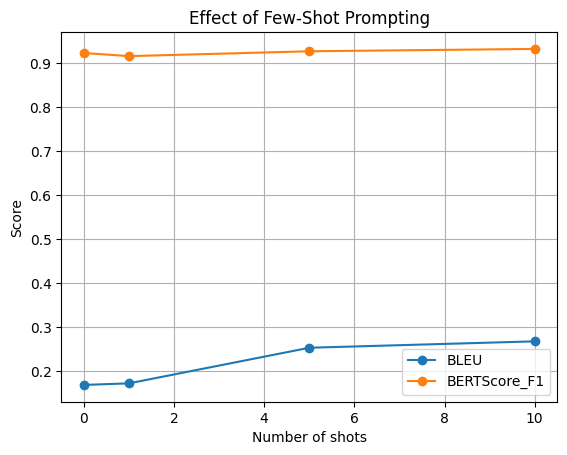

In [ ]:
import matplotlib.pyplot as plt

shots = [0, 1, 5, 10]
bleu = [r["BLEU"] for r in results]
bert = [r["BERTScore_F1"] for r in results]

plt.plot(shots, bleu, marker='o', label="BLEU")
plt.plot(shots, bert, marker='o', label="BERTScore_F1")
plt.xlabel("Number of shots")
plt.ylabel("Score")
plt.title("Effect of Few-Shot Prompting")
plt.legend()
plt.grid(True)
plt.show()
